Goal: Create individual report card for every player in any given match in the statsbomb open data database.

In [1]:
from statsbombpy import sb
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from mplsoccer import Pitch, Sbopen

In [20]:
# A specific match and player to analyze
competition_id = 55
season_id = 282
match_id = 3943043  
team_name = "England"
player_name = "John Stones"

events = sb.events(match_id)
lineups = sb.lineups(match_id)[team_name]

In [26]:
# Match info
competition_name = sb.competitions()[sb.competitions()['competition_id'] == competition_id]['competition_name'].values[0]
season = sb.matches(competition_id, season_id)
match_info = season[season['match_id'] == match_id].iloc[0]
print(f"{competition_name}, {match_info['home_team']} {match_info['home_score']} - {match_info['away_score']} {match_info['away_team']} on {match_info['match_date']}")

UEFA Euro, Spain 2 - 1 England on 2024-07-14


In [4]:
# Player position and time on the pitch
player_info = lineups[lineups['player_name'] == player_name].iloc[0]
positions = player_info["positions"]
position = positions[0]["position"] if isinstance(positions, list) and len(positions) > 0 else None
time_start = positions[0]["from"] if isinstance(positions, list) and len(positions) > 0 else None
time_end = positions[0]["to"] if isinstance(positions, list) and len(positions) > 0 else None
if time_end is None:
    time_end = events['minute'].max()  # Use max timestamp if player is still on the pitch
if player_info["player_nickname"] is not None:
    display_name = player_info["player_nickname"]
else:
    display_name = player_name
print(f"Player: {display_name}")
print(f"Position: {position}")
print(f"Time on pitch: {time_start.split(':')[0]}' to {time_end}'")

Player: John Stones
Position: Right Center Back
Time on pitch: 00' to 94'


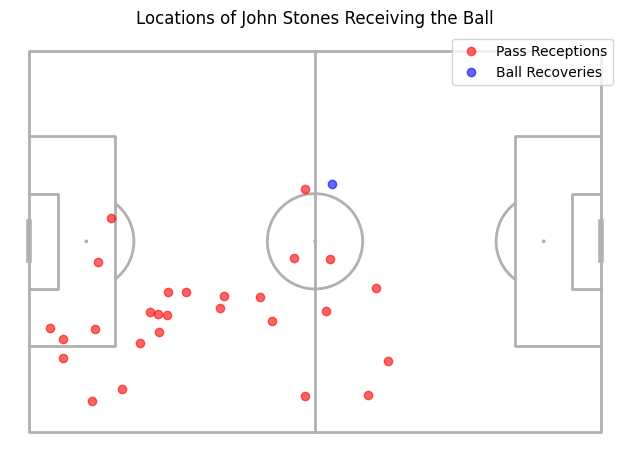

In [5]:
# Ball-receiving locations for the player
pass_receiving_locs = events.loc[
    (events['type'] == 'Pass') & (events['pass_recipient'] == player_name),
    ['pass_end_location']
].dropna().copy()
pass_receiving_locs['x'] = pass_receiving_locs['pass_end_location'].apply(lambda loc: loc[0])
pass_receiving_locs['y'] = pass_receiving_locs['pass_end_location'].apply(lambda loc: loc[1])

# Ball recovery
ball_recoveries = events.loc[
    (events['type'] == 'Ball Recovery') & (events['player'] == player_name) & (events['ball_recovery_recovery_failure'].isna()),
    ['location']
].dropna().copy()
ball_recoveries['x'] = ball_recoveries['location'].apply(lambda loc: loc[0])
ball_recoveries['y'] = ball_recoveries['location'].apply(lambda loc: loc[1])

# Plotting the location of receiving the ball
pitch = Pitch(pitch_type='statsbomb')
fig, ax = pitch.draw()
plt.scatter(pass_receiving_locs['x'], pass_receiving_locs['y'], color='red', alpha=0.6, label='Pass Receptions')
plt.scatter(ball_recoveries['x'], ball_recoveries['y'], color='blue', alpha=0.6, label='Ball Recoveries')
ax.set_title(f'Locations of {player_name} Receiving the Ball')
plt.legend()
plt.show()

In [6]:
# Dribble success rate
dribbles = events.loc[
    (events['type'] == 'Dribble') & (events['player'] == player_name)
].copy()
successful_dribbles = dribbles[dribbles['dribble_outcome'] == 'Complete']
failed_dribbles = dribbles[dribbles['dribble_outcome'] == 'Incomplete']
dribble_success_rate = 100 * len(successful_dribbles) / len(dribbles) if len(dribbles) > 0 else 0
print(f"{player_name}'s Dribble Success Rate: {dribble_success_rate:.2f}% ({len(successful_dribbles)}/{len(dribbles)})")

John Stones's Dribble Success Rate: 0.00% (0/0)


In [ ]:
# Passing success rate
passes = events.loc[
    (events['type'] == 'Pass') & (events['player'] == player_name)
].copy()
successful_passes = passes[passes['pass_outcome'].isna()]
failed_passes = passes[passes['pass_outcome'].isin(['Incomplete', 'Out'])]
passing_success_rate = 100 * len(successful_passes) / len(passes) if len(passes) > 0 else 0
print(f"{player_name}'s Passing Success Rate: {passing_success_rate:.2f}% ({len(successful_passes)}/{len(successful_passes) + len(failed_passes)})")
# Long pass success rate
long_passes = passes[passes['pass_length'] > 30]
successful_long_passes = long_passes[long_passes['pass_outcome'].isna()]
long_pass_success_rate = 100 * len(successful_long_passes) / len(long_passes) if len(long_passes) > 0 else 0
print(f"{player_name}'s Long Pass Success Rate: {long_pass_success_rate:.2f}% ({len(successful_long_passes)}/{len(long_passes)})")

# Passes into final third
passes_into_final_third = passes[passes['pass_end_location'].apply(lambda loc: loc[0] > 80) & passes['location'].apply(lambda loc: loc[0] < 80)]
successful_final_third_passes = passes_into_final_third[passes_into_final_third['pass_outcome'].isna()]
final_third_pass_success_rate = 100 * len(successful_final_third_passes) / len(passes_into_final_third) if len(passes_into_final_third) > 0 else 0
print(f"{player_name}'s Final Third Entry Pass Success Rate: {final_third_pass_success_rate:.2f}% ({len(successful_final_third_passes)}/{len(passes_into_final_third)})")

John Stones's Passing Success Rate: 85.71% (30/35)
John Stones's Long Pass Success Rate: 72.73% (8/11)
John Stones's Final Third Pass Success Rate: 33.33% (2/6)


John Stones took 0 shots with a total xG of 0.00.


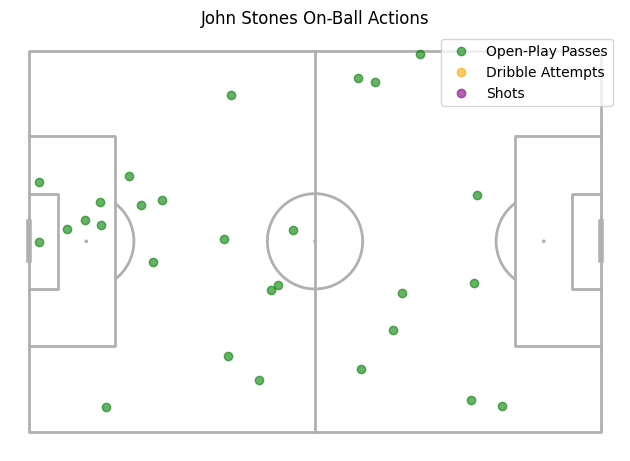

In [8]:
# Offensive actions
# Open-play passes
open_play_passes = passes[passes['pass_type'].isna()]
open_play_passes_locs = open_play_passes['pass_end_location'].dropna().apply(lambda loc: (loc[0], loc[1]))
open_play_passes_locs = pd.DataFrame(open_play_passes_locs.tolist(), columns=['x', 'y'])

# Dribbles
dribble_attempts_locs = dribbles['location'].dropna().apply(lambda loc: (loc[0], loc[1]))
dribble_attempts_locs = pd.DataFrame(dribble_attempts_locs.tolist(), columns=['x', 'y'])

# Shots
shots = events.loc[
    (events['type'] == 'Shot') & (events['player'] == player_name)
].copy()
shot_locs = shots['location'].dropna().apply(lambda loc: (loc[0], loc[1]))
shot_locs = pd.DataFrame(shot_locs.tolist(), columns=['x', 'y'])
shots_xg = shots['shot_statsbomb_xg'].sum()
print(f"{player_name} took {len(shots)} shots with a total xG of {shots_xg:.2f}.")

# Plotting offensive actions
fig, ax = pitch.draw()
plt.scatter(open_play_passes_locs['x'], open_play_passes_locs['y'], color='green', alpha=0.6, label='Open-Play Passes')
plt.scatter(dribble_attempts_locs['x'], dribble_attempts_locs['y'], color='orange', alpha=0.6, label='Dribble Attempts')
plt.scatter(shot_locs['x'], shot_locs['y'], color='purple', alpha=0.6, label='Shots')
ax.set_title(f'{display_name} On-Ball Actions')
plt.legend()
plt.show()

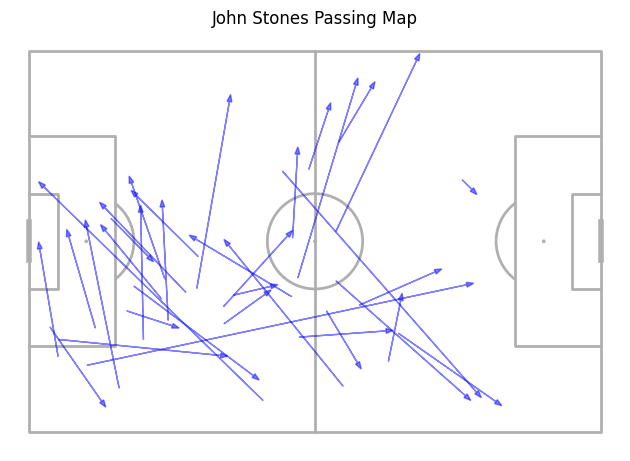

In [9]:
# Passing map
pass_start_locs = passes['location'].dropna().apply(lambda loc: (loc[0], loc[1]))
pass_start_locs = pd.DataFrame(pass_start_locs.tolist(), columns=['x_start', 'y_start'])
pass_end_locs = passes['pass_end_location'].dropna().apply(lambda loc: (loc[0], loc[1]))
pass_end_locs = pd.DataFrame(pass_end_locs.tolist(), columns=['x_end', 'y_end'])
pass_map = pd.concat([pass_start_locs, pass_end_locs], axis=1)
fig, ax = pitch.draw()
for _, row in pass_map.iterrows():
    plt.arrow(row['x_start'], row['y_start'], row['x_end'] - row['x_start'], row['y_end'] - row['y_start'], 
              color='blue', alpha=0.5, head_width=1, length_includes_head=True)
ax.set_title(f'{player_name} Passing Map')
plt.show()

In [10]:
# Defensive actions
# Clearances
clearances = events.loc[
    (events['type'] == 'Clearance') & (events['player'] == player_name)
].copy()
clearances['x'] = clearances['location'].apply(lambda loc: loc[0])
clearances['y'] = clearances['location'].apply(lambda loc: loc[1])
print(f"{player_name} made {len(clearances)} clearances.")
# Interceptions
interception_attempts = events.loc[
    (events['type'] == 'Interception') & (events['player'] == player_name)
].copy()
success_outcomes = ['Won', 'Success', 'Success In Play', 'Success Out']
interception_successes = interception_attempts[
    interception_attempts['interception_outcome'].isin(success_outcomes)
]
interception_rate = (
    100 * len(interception_successes) / len(interception_attempts)
    if len(interception_attempts) > 0 else 0
)
print(f"{player_name}'s Interception Success Rate: {interception_rate:.2f}% ({len(interception_successes)}/{len(interception_attempts)})")
interception_successes['x'] = interception_successes['location'].apply(lambda loc: loc[0])
interception_successes['y'] = interception_successes['location'].apply(lambda loc: loc[1])
# Tackles
tackle_attempts = events.loc[
    (events['type'] == 'Duel') & (events['duel_type'] == 'Tackle') & (events['player'] == player_name)
].copy()
tackle_successes = tackle_attempts[tackle_attempts['duel_outcome'].isin(success_outcomes)]
tackle_rate = (
    100 * len(tackle_successes) / len(tackle_attempts)
    if len(tackle_attempts) > 0 else 0
)
print(f"{player_name}'s Tackle Success Rate: {tackle_rate:.2f}% ({len(tackle_successes)}/{len(tackle_attempts)})")
tackle_successes['x'] = tackle_successes['location'].apply(lambda loc: loc[0])
tackle_successes['y'] = tackle_successes['location'].apply(lambda loc: loc[1])
# Blocks
blocks = events.loc[
    (events['type'] == 'Block') & (events['block_deflection'].isna()) & (events['block_offensive'].isna()) & (events['player'] == player_name)
].copy()
blocks['x'] = blocks['location'].apply(lambda loc: loc[0])
blocks['y'] = blocks['location'].apply(lambda loc: loc[1])
print(f"{player_name} made {len(blocks)} blocks.")

John Stones made 8 clearances.
John Stones's Interception Success Rate: 0.00% (0/0)
John Stones's Tackle Success Rate: 100.00% (1/1)
John Stones made 2 blocks.


John Stones applied pressure 9 times.


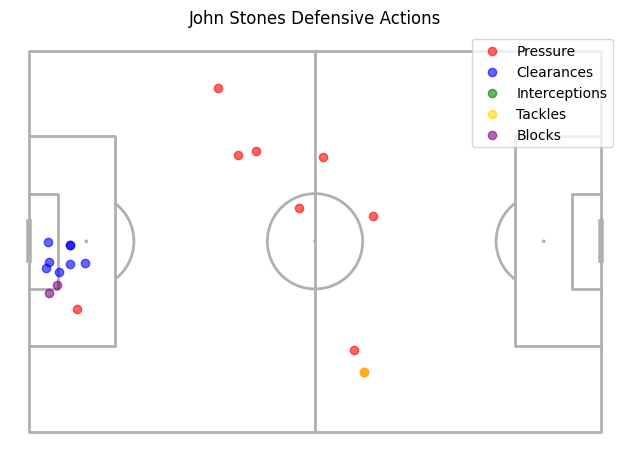

In [11]:
# Pressure events
pressures = events.loc[
    (events['type'] == 'Pressure') & (events['player'] == player_name)
].copy()
pressures['x'] = pressures['location'].apply(lambda loc: loc[0])
pressures['y'] = pressures['location'].apply(lambda loc: loc[1])
print(f"{player_name} applied pressure {len(pressures)} times.")

# Plot defensive actions
pitch = Pitch(pitch_type='statsbomb')
fig, ax = pitch.draw()
plt.scatter(pressures['x'], pressures['y'], color='red', alpha=0.6, label='Pressure')
plt.scatter(clearances['x'], clearances['y'], color='blue', alpha=0.6, label='Clearances')
plt.scatter(interception_successes['x'], interception_successes['y'], color='green', alpha=0.6, label='Interceptions')
plt.scatter(tackle_successes['x'], tackle_successes['y'], color='gold', alpha=0.6, label='Tackles')
plt.scatter(blocks['x'], blocks['y'], color='purple', alpha=0.6, label='Blocks')
plt.title(f'{display_name} Defensive Actions')
plt.legend(loc='upper right')
plt.show()

In [12]:
Fouls_committed = events.loc[
    (events['type'] == 'Foul Committed') & (events['player'] == player_name)
].copy()
print(f"{display_name} committed {len(Fouls_committed)} fouls.")
was_fouled = events.loc[
    (events['type'] == 'Foul Won') & (events['player'] == player_name)
].copy()
print(f"{display_name} was fouled {len(was_fouled)} times.")
player_cards = lineups.loc[lineups['player_name'] == player_name, 'cards']

if player_cards.empty:
    print(f"No card received for {display_name}.")
else:
    cards_data = player_cards.iloc[0]
    if isinstance(cards_data, list):
        cards = [c.get('card_type') for c in cards_data if isinstance(c, dict) and c.get('card_type')]
    elif isinstance(cards_data, dict):
        cards = [cards_data.get('card_type')] if cards_data.get('card_type') else []
    else:
        cards = []

    print(cards if cards else "No cards")

John Stones committed 1 fouls.
John Stones was fouled 0 times.
['Yellow Card']


In [13]:
# Dispossessed, dribbled past and miscontrol events
dispossessed = events.loc[
    (events['type'] == 'Dispossessed') & (events['player'] == player_name)
].copy()
dribbled_past = events.loc[
    (events['type'] == 'Dribbled Past') & (events['player'] == player_name)
].copy()
miscontrol = events.loc[
    (events['type'] == 'Miscontrol') & (events['player'] == player_name)
].copy()
print(f"{display_name} was dispossessed {len(dispossessed)} times.")
print(f"{display_name} was dribbled past {len(dribbled_past)} times.")
print(f"{display_name} had {len(miscontrol)} miscontrols.")

John Stones was dispossessed 0 times.
John Stones was dribbled past 0 times.
John Stones had 0 miscontrols.


In [14]:
# Progressive carries
carries = events.loc[
    (events['type'] == 'Carry') & (events['player'] == player_name)
].copy()
carries['x'] = carries['location'].apply(lambda loc: loc[0])
carries['y'] = carries['location'].apply(lambda loc: loc[1])
# Defining a progressive carry as one that moves the ball at least 10 yards towards the opponent's goal
for idx, carry in carries.iterrows():
    start_x = carry['location'][0]
    end_x = carry['carry_end_location'][0]
    carries.at[idx, 'is_progressive'] = (end_x - start_x) >= 10
progressive_carries = carries[carries['is_progressive']]
print(f"{display_name} made {len(progressive_carries)} progressive carries.")

John Stones made 2 progressive carries.


In [15]:
# Key passes, goal and assists
key_passes = passes[(passes['pass_shot_assist'] == True) | (passes['pass_goal_assist'] == True)]
print(f"{display_name} made {len(key_passes)} key passes.")
assists = passes[passes['pass_goal_assist'] == True]
print(f"{display_name} made {len(assists)} assists.")
goals = shots[shots['shot_outcome'] == 'Goal']
print(f"{display_name} scored {len(goals)} goals.")

John Stones made 0 key passes.
John Stones made 0 assists.
John Stones scored 0 goals.
